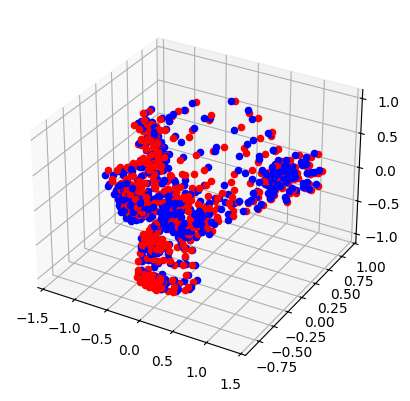

In [2]:
from scipy.spatial.transform import Rotation
import numpy as np
import matplotlib.pyplot as plt
import struct

with open("monkey.ply", "rb") as f:
    raw = f.read()

header_end = raw.index(b"end_header\n") + len(b"end_header\n")
body = raw[header_end:]

n_verts = 555
stride = 5 * 4

verts = set()
for v in range(n_verts):
    x, y, z = struct.unpack('<3f', body[v * stride: v * stride + 12])
    verts.add(((x, y, z)))

verts = np.array([v for v in verts if len(v) == 3])

fig = plt.figure()
ax = fig.add_subplot(projection='3d')


def scatter_points(verts, color):
    for x, y, z in verts:
        ax.scatter(x, y, z, marker="o", c=color)


scatter_points(verts, "blue")

# R_mat = np.array([
#     [1, 0, 0],
#     [0, 0, 1],
#     [0, -1, 0]
# ])


R_mat = Rotation.from_euler('xyz', [-5, 2, 3], degrees=True).as_matrix()

r_verts = (R_mat @ verts.T).T

scatter_points(r_verts, "red")

plt.show()

In [3]:
import numpy as np
from scipy import linalg

"""How to get from B to A"""
def umeyama(A, B, dims):
    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)
    A_centered = A - centroid_A
    B_centered = B - centroid_B

    H = A_centered.T @ B_centered
    U, _S, Vt = linalg.svd(H)
    d = linalg.det(U @ Vt)
    reflect = np.eye(dims) * [*([1] * (dims - 1)), d]
    R = U @ reflect @ Vt
    t = centroid_A - R @ centroid_B
    return R, t

In [4]:
R, t = umeyama(r_verts, verts, dims = 3)
print("Original:\n", R_mat)
print(np.round(R, decimals=3))

Original:
 [[ 0.9980212  -0.05517433  0.03015767]
 [ 0.05230407  0.99467026  0.08885585]
 [-0.0348995  -0.08710265  0.99558784]]
[[ 0.998 -0.055  0.03 ]
 [ 0.052  0.995  0.089]
 [-0.035 -0.087  0.996]]


In [5]:
from scipy.spatial import KDTree

class KDNode:
    def __init__(self, pivot, left = None, right = None, leaf = False):
        self.pivot = pivot
        self.left = left
        self.right = right
        self.leaf = leaf
    
    def next(self, point, index):
        if point[index] >= self.pivot[index]:
            return self.right
        return self.left

class PyKDTree:
    def __init__(self, M, dims):
        self.dims = dims
        M = np.array(M)
        self.root = self.build(M)
    
    def build(self, M, depth = 0):
        if len(M) == 1:
            return KDNode(M[0], leaf = True)
        index = depth % self.dims
        M_sorted = M[np.argsort(M[:, index])]
        pivot = len(M_sorted) // 2
        pivot_item = M_sorted[pivot]
        left = self.build(M_sorted[:pivot], depth + 1)
        right = self.build(M_sorted[pivot:], depth + 1)
        return KDNode(pivot_item, left, right, leaf = False)

    def search(self, point, depth = 0, start=None, best = None):
        start = self.root if start is None else start
        if start.leaf:
            dist = np.linalg.norm(point - start.pivot)
            if best is None or dist < best[1]:
                return (start.pivot, dist)
            return best

        index = depth % self.dims

        if point[index] >= start.pivot[index]:
            first, second = start.right, start.left
        else:
            first, second = start.left, start.right

        # if splitting plane is closer than best, need to check other side
        best = self.search(point, depth + 1, first, best)
        plane_dist = abs(point[index] - start.pivot[index])
        if plane_dist < best[1]:
            best = self.search(point, depth + 1, second, best)

        dist = np.linalg.norm(point - start.pivot)
        if dist < best[1]:
            best = (start.pivot, dist)

        return best
            

def icp(A, B, max_iters=50, tol=1e-6, dims=3):
    # # naive linalg norm
    # A_mapped = np.array([B[np.argmin(np.linalg.norm(B - v_a, axis=1))] for v_a in A])

    # # our KDTree implementation
    # tree = PyKDTree(A, dims)
    # A_mapped = np.array([tree.search(v_b)[0] for v_b in B])

    R_total, t_total = np.eye(dims), np.zeros(dims)
    B_new = B.copy()
    tree = KDTree(A)
    for i in range(max_iters):
        distances, indices = tree.query(B_new)
        A_mapped = A[indices]
        R, t = umeyama(A_mapped, B_new, dims)
        B_new = (R @ B_new.T).T + t
        mean_error = np.mean(distances)
        R_total = R @ R_total
        t_total = R @ t_total + t
        if mean_error < tol:
            break
    return R_total, t_total

A = verts.copy()
B = r_verts.copy() + np.random.normal(0, 0.005, r_verts.shape)
np.random.shuffle(B)
print("Original rotation: ", R)
R_icp, t = icp(B, A, dims=3)
print("ICP Rotation: ", R_icp)
print("Offset: ", t)
print("Resultant Euler: ", Rotation.from_matrix(R_icp).as_euler("xyz", degrees=True))

Original rotation:  [[ 0.9980212  -0.05517433  0.03015767]
 [ 0.05230407  0.99467026  0.08885585]
 [-0.0348995  -0.08710265  0.99558784]]
ICP Rotation:  [[ 0.99803405 -0.05488152  0.03026623]
 [ 0.05199544  0.99466775  0.08906483]
 [-0.03499285 -0.08731603  0.99556588]]
Offset:  [ 9.19657178e-05 -2.57140240e-05  1.75688664e-04]
Resultant Euler:  [-5.01229624  2.00535212  2.98229128]
